In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# READING IN ELEXON DATASET

def read_elexon_data(csv_file):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_file)

    # Ensure the 'Date' column is in datetime format
    df['PublishTime'] = pd.to_datetime(df['PublishTime'])
    df['SettlementDate'] = pd.to_datetime(df['SettlementDate'])
    df['StartTime'] = pd.to_datetime(df['StartTime'])

    df = df.sort_values(by='PublishTime', ascending=True, kind='stable')

    df = df.reset_index() #override the original index positioning in the unorganised csv 

    current_year = df['SettlementDate'].loc[21]

    # to remove edge effects
    df = df[df['SettlementDate'] >= current_year]

    # ** ai generated code **
    df = df.pivot_table(
        index=['PublishTime', 'SettlementDate'],
        columns='FuelType', # turn fuel types into columns
        values='Generation', # assign the generation values to the new columns
    ).reset_index()

    df.columns.name = None
    df['GAS'] = df['CCGT'] + df['OCGT']
    inter_cols = [col for col in df.columns if 'INT' in col] 
    df['INTERCONNECTORS'] = df[inter_cols].sum(axis=1)
    df = df.drop(columns=['CCGT', 'OCGT'] + inter_cols)

    return df


# READING IN NESO DATASET

def read_neso_data(csv_file):
    df = pd.read_csv(csv_file)
    
    df['Forecast_Datetime'] = pd.to_datetime(df['Forecast_Datetime'])
    df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'])

    # kwarg: error='coerce' as there are values under the time column that do not adhere to the required hh:mm:ss  
    # format that the function pd.to_timedelta requires 
    
    df['TIME_GMT'] = pd.to_timedelta(df['TIME_GMT'], errors='coerce') 

    df['PublishTime'] = df['SETTLEMENT_DATE'] + df['TIME_GMT']

    df = df.sort_values(by='SETTLEMENT_DATE', ascending=True, kind='stable')

    sameday = (df["SETTLEMENT_DATE"].dt.normalize() == df["Forecast_Datetime"].dt.normalize())

    df = df[sameday]

    df = df.drop_duplicates(subset=["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"], keep="first")

    df = df.reset_index(drop=True).drop(columns=['DATE_GMT'])
 
    return df

# COMBINING BOTH DATASETS

def merged_datasets(elexon_csv, neso_csv):

    a = read_elexon_data(elexon_csv)
    b = read_neso_data(neso_csv)

    df = a.merge(b)

    df['WIND'] = df['WIND'] + df['EMBEDDED_WIND_FORECAST']
    df = df.drop(columns=['TIME_GMT', 'SETTLEMENT_DATE', 'Forecast_Datetime'])
    df = df.rename(columns={'EMBEDDED_SOLAR_FORECAST': 'SOLAR'})
    df = df.assign(DEMAND = df.BIOMASS + df.COAL +  df.NPSHYD +
                            df.NUCLEAR + df.OIL+ df.OTHER +
                            df.PS + df.WIND + df.GAS + df.SOLAR)
    
    return df 

comb_2020 = merged_datasets('Elexon2020.csv', 'NESO2020.csv')
comb_2021 = merged_datasets('Elexon2021.csv', 'NESO2021.csv')
comb_2022 = merged_datasets('Elexon2022.csv', 'NESO2022.csv')
comb_2023 = merged_datasets('Elexon2023.csv', 'NESO2023.csv')
comb_2024 = merged_datasets('Elexon2024.csv', 'NESO2024.csv')



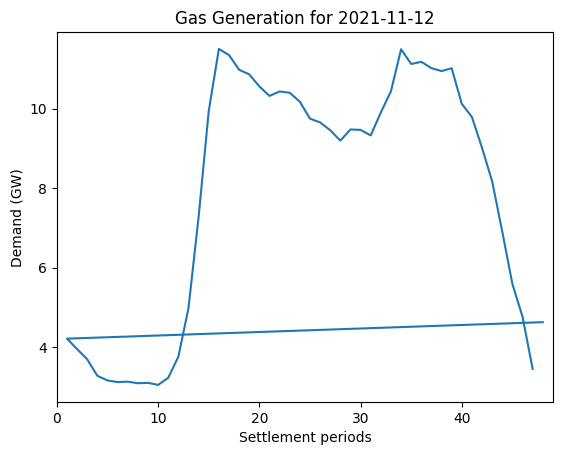

In [7]:
# DAILY PLOT FUNCTION

def daily_plot(dataset, column_name, date):
    df_24h = dataset.set_index("SettlementDate").loc[date]

    x = df_24h["SETTLEMENT_PERIOD"]
    y = df_24h[column_name]/1000

    plt.plot(x, y)

    plt.title(f"{column_name.capitalize()} Generation for {date}")
    plt.xlabel("Settlement periods")
    plt.ylabel("Demand (GW)")
    plt.xlim(0, x.max()+1)
    plt.show()

    return

daily_plot(comb_2021, "GAS", "2021-11-12")

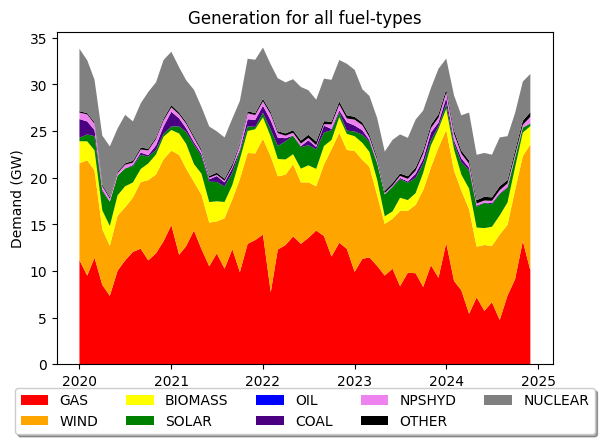

In [8]:
# STACKED ALL-YEAR PLOT
all_years = [comb_2020, comb_2021, comb_2022, comb_2023, comb_2024]

df = pd.concat(all_years)

df = df.set_index("SettlementDate")

all_yr_df = df.resample("MS").mean()

fig=plt.figure()
ax = plt.subplot(111)
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

x = all_yr_df.index
y = all_yr_df["GAS"]/1000
a = all_yr_df["WIND"]/1000
b = all_yr_df["BIOMASS"]/1000
c = all_yr_df["SOLAR"]/1000
d = all_yr_df["OIL"]/1000
e = all_yr_df["COAL"]/1000
f = all_yr_df["NPSHYD"]/1000
g = all_yr_df["OTHER"]/1000
h = all_yr_df["NUCLEAR"]/1000

cols = [y,a,b,c,d,e,f,g,h]

colors=['red','orange','yellow','green','blue','indigo','violet','black','grey']
labels = ["GAS","WIND","BIOMASS","SOLAR","OIL","COAL","NPSHYD","OTHER","NUCLEAR"]

plt.plot([], [], label="GAS")
plt.plot([],[], label='WIND')
plt.plot([],[], label='BIOMASS')
plt.plot([],[], label='SOLAR')
plt.plot([],[], label='OIL')
plt.plot([],[], label='COAL')
plt.plot([],[], label='NPSHYD')
plt.plot([],[], label='OTHER')
plt.plot([],[], label='NUCLEAR')


stacked = plt.stackplot(x, cols,colors=colors, baseline='zero')
plt.title("Generation for all fuel-types")
plt.xlabel("Year")
plt.ylabel("Demand (GW)")
ax.legend(stacked, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)
plt.show()



16.508637096774194


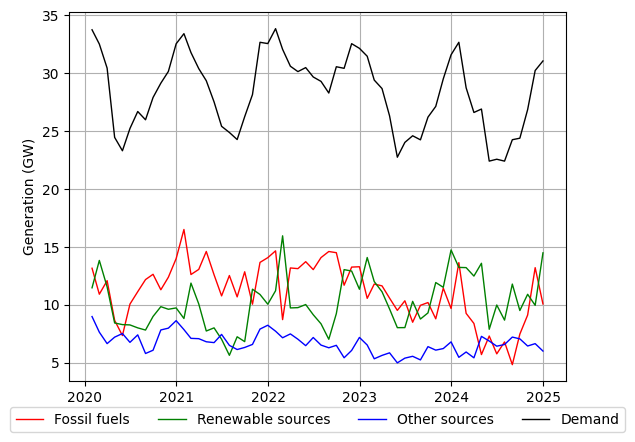

In [12]:
# ALL YEAR PLOT, 3 CATEGORIES

all_years = [comb_2020, comb_2021, comb_2022, comb_2023, comb_2024]

df = pd.concat(all_years)

df = df.set_index("SettlementDate")

all_yr_df = df.resample("ME").mean()

x = all_yr_df.index

FF = (all_yr_df["GAS"] + 
    all_yr_df["OIL"] + 
    all_yr_df["COAL"])
FossilFuel = FF/1000

print(FossilFuel.max())

REN = (all_yr_df["WIND"]+
    all_yr_df["SOLAR"]+
    all_yr_df["NPSHYD"])

Renewables = REN/1000

OTH = (all_yr_df["NUCLEAR"]+
       all_yr_df["BIOMASS"]+
       all_yr_df["PS"])
Other = OTH/1000 

y = all_yr_df["GAS"]/1000
a = all_yr_df["WIND"]/1000
b = all_yr_df["BIOMASS"]/1000
c = all_yr_df["SOLAR"]/1000
d = all_yr_df["OIL"]/1000
e = all_yr_df["COAL"]/1000
f = all_yr_df["NPSHYD"]/1000
g = all_yr_df["OTHER"]/1000
h = all_yr_df["NUCLEAR"]/1000
#i = all_yr_df["INTERCONNECTORS"]/1000
j = all_yr_df["PS"]/1000
k = all_yr_df["DEMAND"]/1000


"""plt.plot(x,y, label="GAS",color='orange', linewidth=lw)
plt.plot(x,a, label='WIND',color='cornflowerblue', linewidth=lw)
plt.plot(x,h,label='NUCLEAR',color='limegreen', linewidth=lw)
plt.plot(x,b,label='BIOMASS',color='yellowgreen', linewidth=lw)
plt.plot(x,c,label='SOLAR',color='gold', linewidth=lw)
plt.plot(x,d,label='OIL',color='maroon', linewidth=lw)
plt.plot(x,e, label='COAL',color='mediumorchid', linewidth=lw)
plt.plot(x,f,label='NPSHYD',color='steelblue', linewidth=lw)
plt.plot(x,g,label='OTHER',color='grey', linewidth=lw)
plt.plot(x,j,label='PS',color='blue', linewidth=lw)
"""
lw=1

plt.plot(x, FossilFuel, label="Fossil fuels", linewidth=lw, color='red')
plt.plot(x, Renewables, label="Renewable sources",linewidth=lw, color='green')
plt.plot(x, Other,label="Other sources", linewidth=lw, color='blue')
plt.plot(x,k,label='Demand',color='black', linewidth=lw)
#plt.plot(x,i,label='INTERCONNECTORS',color='blueviolet') # careful defining interconnectors as generation

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=False, ncol=5)
plt.ylabel("Generation (GW)")
plt.grid()
plt.show()



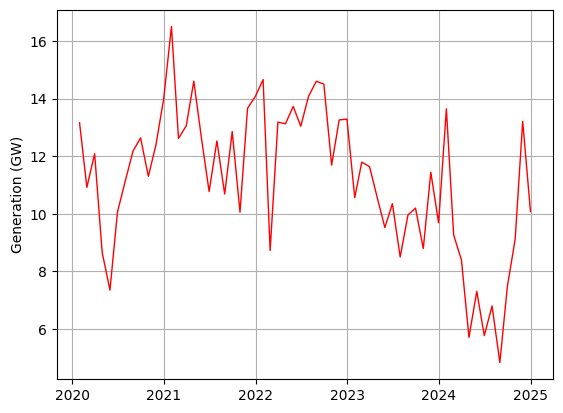

In [5]:
# FOSSIL FUEL PLOT
plt.plot(x, FossilFuel,linewidth=lw, color='red')
plt.ylabel("Generation (GW)")
plt.grid()
plt.show()

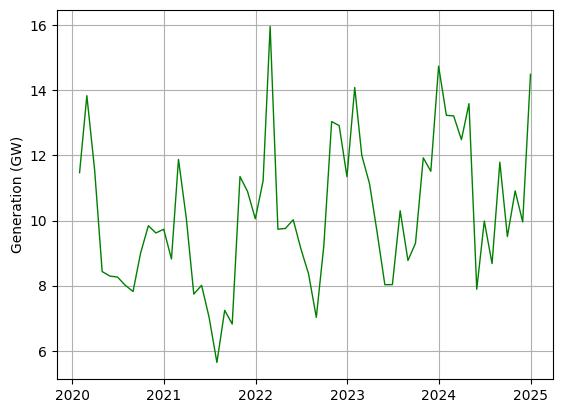

In [6]:
# RENEWABLES PLOT
import numpy as np

plt.plot(x, Renewables, label="Renewables", linewidth=lw, color='green')
plt.ylabel("Generation (GW)")
#plt.yticks(np.arange(6, 17))
plt.grid()
plt.show()


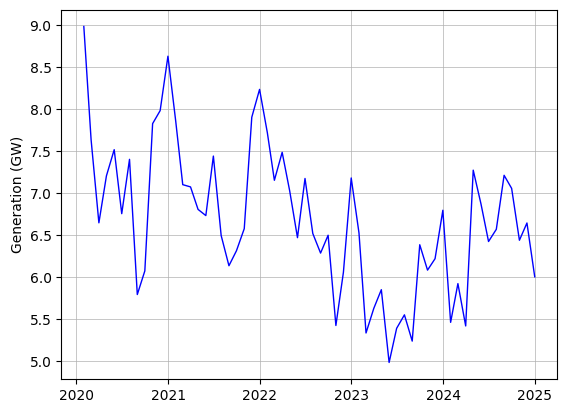

In [7]:
# OTHER SOURCES PLOT
plt.plot(x, Other,linewidth=lw, color='blue')
plt.ylabel("Generation (GW)")
plt.grid(linewidth=0.5)
#plt.yticks(np.arange(5, 9.5, 0.5))
plt.show()

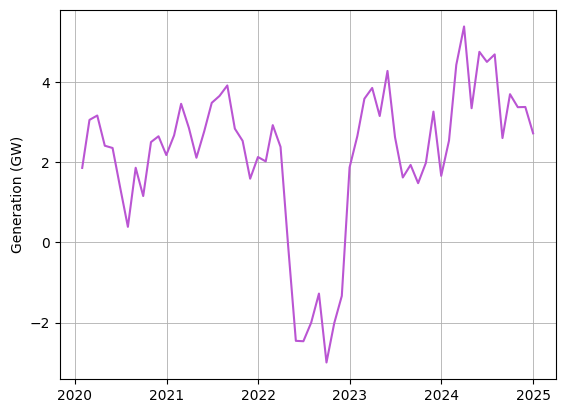

In [8]:
# ALL YEAR PLOT FUNCTION

import numpy as np

def all_year(column_name, time_interval):

    all_years = [comb_2020, comb_2021, comb_2022, comb_2023, comb_2024]

    # make one big dataframe 
    df = pd.concat(all_years)

    df = df.set_index("SettlementDate")

    all_yr_df = df.resample(time_interval).mean()
    
    x = all_yr_df.index

    FF = (all_yr_df["GAS"] + 
        all_yr_df["OIL"] + 
        all_yr_df["COAL"])
    FossilFuel = FF/1000

    REN = (all_yr_df["WIND"]+
        all_yr_df["SOLAR"]+
        all_yr_df["NPSHYD"])

    Renewables = REN/1000

    OTH = (all_yr_df["NUCLEAR"]+
        all_yr_df["BIOMASS"]+
        all_yr_df["PS"])
    Other = OTH/1000

    color = None
    if column_name == "GAS":
        color = 'orange'
    elif column_name == "NUCLEAR":
        color = 'limegreen'
    elif column_name == "INTERCONNECTORS":
        color = 'mediumorchid'
    elif column_name == "EMBEDDED_SOLAR_CAPACITY":
        color = 'gold'

    ylabel=None
    if 'CAPACITY' in column_name:
        ylabel="Installed capacity (GW)"
    else: 
        ylabel="Generation (GW)"

    lw = 1.5
    x = all_yr_df.index
    y = all_yr_df[column_name]/1000
    plt.plot(x,y, label=column_name, color = color, linewidth=lw)
    plt.ylabel(ylabel)
    #plt.legend()
    plt.grid(linewidth=0.6)
    plt.show()

    return 

all_year("INTERCONNECTORS", "ME")

In [9]:
# one year demand plot

def one_year(dataset, time_interval, column_name):

    df = dataset.set_index("SettlementDate")
    one_year_df = df.resample(time_interval).mean()

    FF = (one_year_df["GAS"] + 
        one_year_df["OIL"] + 
        one_year_df["COAL"])
    
    FossilFuel = FF/1000


    """MaxFossilFuel = FossilFuel.idxmax()
    print(f"The date of the maximum value is: {MaxFossilFuel}")
    MaxFF = FossilFuel.max()
    print(f"The maximum value is: {np.round(MaxFF, 2)}")

    MinFossilFuel = FossilFuel.idxmin()
    print(f"The date of the minimum value is: {MinFossilFuel}")
    MinFF = FossilFuel.min()
    print(f"The minimum value is: {np.round(MinFF, 2)}")
    print(f"The average FF generation for this year is {np.round(np.mean(FossilFuel), 2)}\n")"""

    REN = (one_year_df["WIND"]+
        one_year_df["SOLAR"]+
        one_year_df["NPSHYD"])

    Renewables = REN/1000


    """ MaxRen = Renewables.idxmax()
    print(f"The date of the maximum value is: {MaxRen}")
    MaxRenewables = Renewables.max()
    print(f"The maximum value is: {np.round(MaxRenewables, 2)}")

    MinRenewables = Renewables.idxmin()
    print(f"The date of the minimum value is: {MinRenewables}")
    MinREN = Renewables.min()
    print(f"The minimum value is: {np.round(MinREN, 2)}")
    print(f"The average renewable generation for this year is {np.round(np.mean(Renewables))}\n")"""


    OTH = (one_year_df["NUCLEAR"]+
        one_year_df["BIOMASS"]+
        one_year_df["PS"])
    
    Other = OTH/1000

    """MaxOth = Other.idxmax()
    print(f"The date of the maximum value is: {MaxOth}")
    MaxOTH = Other.max()
    print(f"The maximum value is: {np.round(MaxOTH, 2)}")

    MinOth = Other.idxmin()
    print(f"The date of the minimum value is: {MinOth}")
    MinOTH = FossilFuel.min()
    print(f"The minimum value is: {np.round(MinOTH, 2)}")
    print(f"The average OTH generation for this year is {np.round(np.mean(Other), 2)}\n")
    """

    """ylabel=None
    if 'CAPACITY' in column_name:
        ylabel="Capacity (GW)"
    else: 
        ylabel="Generation (GW)"

    color = None
    if column_name == "GAS":
        color = 'darkorange'
    elif column_name == "NUCLEAR":
        color = 'limegreen'

    lw = 0.7
    x = one_year_df.index
    y = one_year_df[column_name]/1000
    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.grid(linewidth=0.5)
    plt.plot(x,y, label=column_name, color=color, linewidth=lw)
    plt.show()"""

    
    #print(f"The date of the maximum value is: {Max}")
    DateMax = (one_year_df[column_name]/1000).idxmax()
    DateMin = (one_year_df[column_name]/1000).idxmin()
    Max = (one_year_df[column_name]/1000).max()
    Min = (one_year_df[column_name]/1000).min()
    print(f"The maximum value is: {np.round(Max, 2)} and the minimum value is: {np.round(Min, 2)}")

    print(f"Max occurs at: {DateMax} and min occurs at: {DateMin}")

    print(f"The average for this year is {np.round(np.mean(one_year_df[column_name]/1000), 2)} GW \n")


    return

"""if "2022-01-02" in comb_2021["SettlementDate"]:
    print("Yes")
else: 
    print("No")"""


one_year(comb_2020, "D", "INTERCONNECTORS")
one_year(comb_2021, "D", "INTERCONNECTORS")
one_year(comb_2022, "D", "INTERCONNECTORS")
one_year(comb_2023, "D", "INTERCONNECTORS")
one_year(comb_2024, "D", "INTERCONNECTORS")





The maximum value is: 4.2 and the minimum value is: -1.84
Max occurs at: 2020-03-30 00:00:00 and min occurs at: 2020-07-02 00:00:00
The average for this year is 2.07 GW 

The maximum value is: 4.97 and the minimum value is: -0.8
Max occurs at: 2021-08-20 00:00:00 and min occurs at: 2021-04-08 00:00:00
The average for this year is 2.83 GW 

The maximum value is: 5.0 and the minimum value is: -5.06
Max occurs at: 2022-12-22 00:00:00 and min occurs at: 2022-11-26 00:00:00
The average for this year is -0.46 GW 

The maximum value is: 6.66 and the minimum value is: -2.89
Max occurs at: 2023-03-11 00:00:00 and min occurs at: 2023-12-07 00:00:00
The average for this year is 2.67 GW 

The maximum value is: 7.45 and the minimum value is: -3.19
Max occurs at: 2024-02-25 00:00:00 and min occurs at: 2024-01-09 00:00:00
The average for this year is 3.78 GW 



In [10]:
# ALL YEAR VALUE GENERATION FUNC

def cap_val_all(time_interval, column_name):

    all_years = [comb_2020, comb_2021, comb_2022, comb_2023, comb_2024]

    df = pd.concat(all_years)

    df = df.set_index("SettlementDate")

    all_yr_df = df.resample("ME").mean()
    
    capacity_vals = np.round((all_yr_df[column_name].unique())/1000, 2)
    print(capacity_vals)

    return

cap_val_all("ME", "DEMAND")


[33.76 32.53 30.45 24.46 23.31 25.23 26.7  25.99 27.91 29.15 30.16 32.55
 33.43 31.79 30.41 29.36 27.53 25.42 24.89 24.28 26.26 28.16 32.68 32.57
 33.86 32.07 30.61 30.15 30.49 29.68 29.3  28.3  30.57 30.43 32.56 32.16
 31.48 29.42 28.68 26.33 22.75 24.03 24.6  24.25 26.21 27.14 29.52 31.6
 32.68 28.75 26.62 26.91 22.42 22.58 22.41 24.26 24.39 26.87 30.24 31.07]


In [11]:
# SINGLE YEAR VALUE GENERATION FUNC

def val_one(dataset, time_interval, column_name):

    df = dataset.set_index("SettlementDate")
    one_year_df = df.resample(time_interval).mean()

    """capacity_vals = np.round((one_year_df[column_name].unique())/1000, 2)
    mean_cap_val = np.round(capacity_vals.mean(), 2)
    print(mean_cap_val)"""

    """ max_fore = (one_year_df[column_name].max())/1000 
    max_cap = (one_year_df[col2].max())/1000
    maxpercent = max_fore / max_cap 
    print(np.round(maxpercent, 3))"""

    demand = (one_year_df["DEMAND"].mean())/1000
    print(np.round((demand), 2))
    
    return

val_one(comb_2024, "ME", "DEMAND")


26.6


In [12]:
# obtaining max values

def max_values(dataset, column_name, num_vals):
    max = read_elexon_data(dataset).nlargest(num_vals, column_name)[["PublishTime", column_name]].sort_values(by=[column_name],ascending=True)
    return (print(max))

def min_values(dataset, column_name, num_vals):
    min = read_elexon_data(dataset).nsmallest(num_vals, column_name)[["PublishTime", column_name]].sort_values(by=[column_name],ascending=True)
    return (print(min))

windcap = "EMBEDDED_WIND_CAPACITY"
windfore = "EMBEDDED_WIND_FORECAST"
solarcap = "EMBEDDED_SOLAR_CAPACITY"
solarfore = "SOLAR"



8.29
8.83


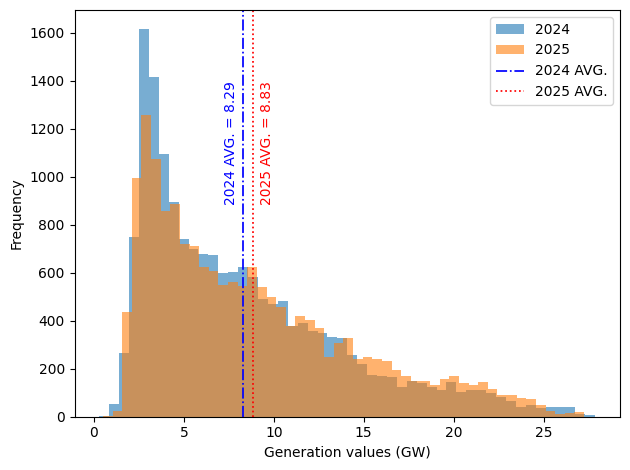

In [13]:
# creating a histogram of gas generation values

from labellines import labelLines
import numpy as np

def histogram(df1, column_name, df2=None):
    vals1 = df1[column_name]/1000
    df1_mean = vals1.mean()

    print(np.round(df1_mean, 2))

    vals2 = df2/1000 
    df2_mean = vals2.mean()

    print(np.round(df2_mean, 2))

    alpha = 0.6
    lw=1.25
    gas_hist1 = vals1.hist(bins=50, alpha=alpha, grid=False, label='2024', histtype='stepfilled')
    gas_hist2 = vals2.hist(bins=50,  alpha=alpha, grid=False, label='2025', histtype='stepfilled')
    plt.axvline(df1_mean, color = 'blue', markeredgecolor='black', linestyle='-.', linewidth = lw, label='2024 AVG.')
    plt.axvline(df2_mean, color = 'red', linestyle=':', linewidth = lw, label='2025 AVG.')
    plt.xlabel("Generation values (GW)")
    plt.ylabel("Frequency")
    plt.text(8, 1400, '2024 AVG. = 8.29', ha='right', va='top', rotation=90, color='blue')
    plt.text(10, 1400, '2025 AVG. = 8.83', ha='right', va='top', rotation=90, color='red')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

Elexon2025 = read_elexon_data('Elexon2025.csv')
histogram(comb_2024,'GAS', Elexon2025['GAS'])



0.266


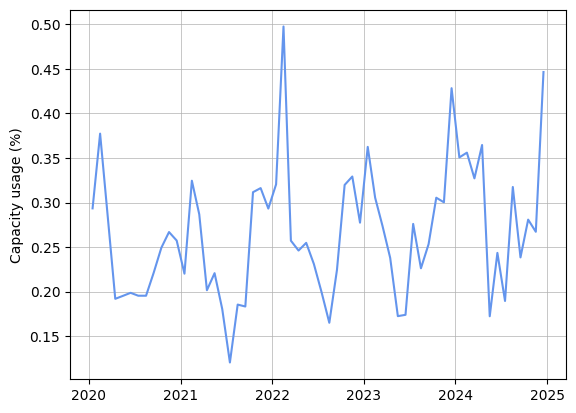

0.099


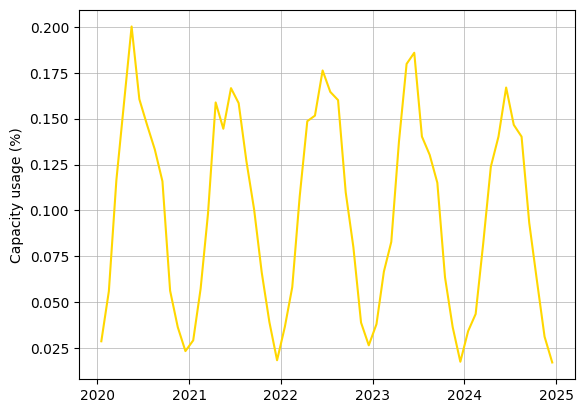

In [14]:
# EMBEDDED GENERATION CAPACITY PERCENTAGE

"""comb_2024["margin_value"] = (comb_2024["EMBEDDED_WIND_FORECAST"])/comb_2024["EMBEDDED_WIND_CAPACITY"]

print(comb_2024.columns)

new_df = comb_2024.set_index("SettlementDate")
wind_cap_margin = new_df.resample("W").mean()

x = wind_cap_margin["PublishTime"]
y = wind_cap_margin["margin_value"]

plt.plot(x,y)
plt.show()"""

all_years = [comb_2020, comb_2021, comb_2022, comb_2023, comb_2024]
allyeardf = pd.concat(all_years)

def capacity_percentage(dataset, forecast, capacity):

    dataset["margin_value"] = dataset[forecast]/dataset[capacity]

    new_df = dataset.set_index("SettlementDate")
    wind_cap_margin = new_df.resample("ME").mean()
    average = wind_cap_margin["margin_value"].mean()

    print(np.round(average, 3))


    x = wind_cap_margin["PublishTime"]
    y = wind_cap_margin["margin_value"]

    color=None
    if 'WIND' in forecast:
        color='cornflowerblue'
    else: 
        color='gold'

    plt.plot(x,y, color=color)
    plt.ylabel("Capacity usage (%)")
    plt.grid(linewidth=0.5)
    plt.show()

    return

windcap = "EMBEDDED_WIND_CAPACITY"
windfore = "EMBEDDED_WIND_FORECAST"

solarcap = "EMBEDDED_SOLAR_CAPACITY"
solarfore = "SOLAR"

capacity_percentage(allyeardf, windfore, windcap)
capacity_percentage(allyeardf, solarfore, solarcap)


In [15]:
print((comb_2024["EMBEDDED_WIND_CAPACITY"].tail(1))/1000)

17513    6.606
Name: EMBEDDED_WIND_CAPACITY, dtype: float64


0.266
0.099


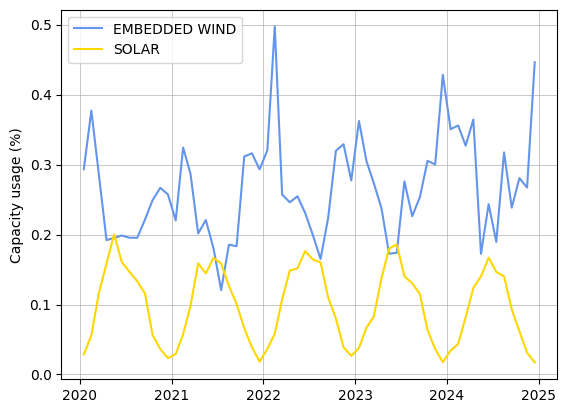

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def capacity_percentage(dataset, forecast, capacity, ax=None, show=True):

    dataset["margin_value"] = dataset[forecast] / dataset[capacity]

    new_df = dataset.set_index("SettlementDate")
    wind_cap_margin = new_df.resample("ME").mean()
    average = wind_cap_margin["margin_value"].mean()

    print(np.round(average, 3))

    x = wind_cap_margin["PublishTime"]
    y = wind_cap_margin["margin_value"]

    color = 'cornflowerblue' if 'WIND' in forecast else 'gold'

    # Use provided axis or default pyplot
    if ax is None:
        ax = plt.gca()

    label=None
    if 'WIND' in forecast:
        label='EMBEDDED WIND'
    else: 
        label='SOLAR'

    ax.plot(x, y, color=color, label=label)

    ax.set_ylabel("Capacity usage (%)")
    ax.grid(linewidth=0.5)

    if show:
        ax.legend()
        plt.show()

    return

fig, ax = plt.subplots()

capacity_percentage(allyeardf, "EMBEDDED_WIND_FORECAST", "EMBEDDED_WIND_CAPACITY", ax=ax, show=False)
# should it be embedded solar (even though there is no distinction, because solar is not connected directly connected to the HV network?)
capacity_percentage(allyeardf, "SOLAR", "EMBEDDED_SOLAR_CAPACITY", ax=ax, show=True)

8.29
8.83


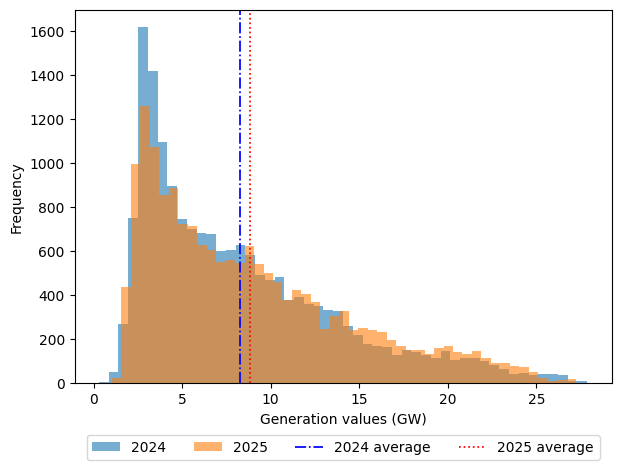

In [17]:
    #plt.text(8, 1400, '2024 AVG. = 8.29', ha='right', va='top', rotation=90, color='blue')
    #plt.text(10, 1400, '2025 AVG. = 8.83', ha='right', va='top', rotation=90, color='red')
from labellines import labelLines
import numpy as np
import matplotlib.pyplot as plt

def histogram(df1, column_name, df2=None):
    vals1 = df1[column_name] / 1000
    df1_mean = vals1.mean()
    print(np.round(df1_mean, 2))

    vals2 = df2 / 1000 
    df2_mean = vals2.mean()
    print(np.round(df2_mean, 2))

    alpha = 0.6
    lw = 1.25

    vals1.hist(bins=50, alpha=alpha, grid=False, label='2024', histtype='stepfilled')
    vals2.hist(bins=50, alpha=alpha, grid=False, label='2025', histtype='stepfilled')

    plt.axvline(df1_mean, color='blue', linestyle='-.', linewidth=lw, label='2024 average')
    plt.axvline(df2_mean, color='red', linestyle=':', linewidth=lw, label='2025 average')

    plt.xlabel("Generation values (GW)")
    plt.ylabel("Frequency")

    # Legend BELOW the plot
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),  # push further down if needed
        fancybox=True,
        shadow=False,
        ncol=4
    )

    plt.tight_layout()  # prevents clipping
    plt.show()

Elexon2025 = read_elexon_data('Elexon2025.csv')
histogram(comb_2024,'GAS', Elexon2025['GAS'])


## Model 1: Pumped storage reliance

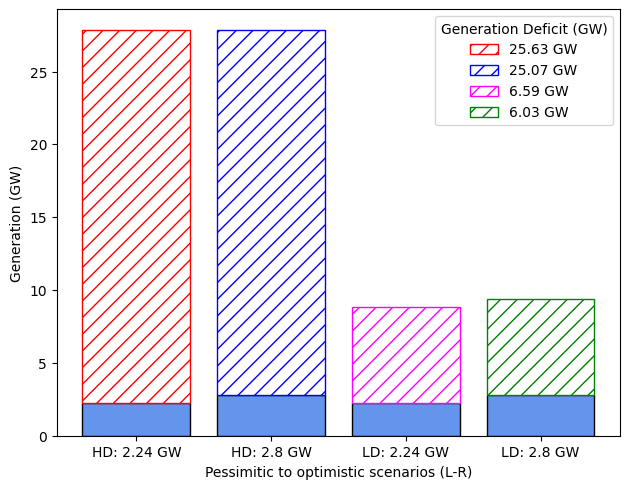

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# create data
x1 = ['HD: 2.24 GW']
x2 = ['HD: 2.8 GW']
x3 = ['LD: 2.24 GW']
x4 = ['LD: 2.8 GW']
y1 = 2.24
y2 = 2.8
y3 = np.array([(27.87-2.24)])
y4 = np.array([(27.87-2.8)])
y5 = np.array([(8.83-2.24)])
y6= np.array([(8.83-2.8)])
#y3 = np.array([12, 15, 19, 6])
#y4 = np.array([10, 29, 13, 19])

# plot bars in stack manner
alpha=1
color='cornflowerblue'
plt.bar(x1, y1, color=color,edgecolor='black')
plt.bar(x1, y3, bottom=y1, color='white', alpha=alpha, hatch='//',edgecolor='red', label = '25.63 GW')
plt.bar(x2, y2, color=color,edgecolor='black')
plt.bar(x2, y4, bottom=y2, color='white',  alpha=alpha, hatch='//',edgecolor='blue', label = '25.07 GW')
plt.bar(x3,y1, color=color,edgecolor='black')
plt.bar(x3, y5, bottom=y1, color='white', alpha=alpha, hatch='//',edgecolor='magenta', label = '6.59 GW')
plt.bar(x4, y2,color=color,edgecolor='black')
plt.bar(x4, y5,  bottom=y2, color='white', alpha=alpha, hatch='//',edgecolor='green', label = '6.03 GW')
plt.ylabel("Generation (GW)")
plt.legend(ncol=1, title='Generation Deficit (GW)')
#plt.xticks(rotation=45, ha='right')

plt.tight_layout()  # prevents clipping
plt.xlabel("Pessimitic to optimistic scenarios (L-R)")
plt.show()

## Model 2: Increasing renewables

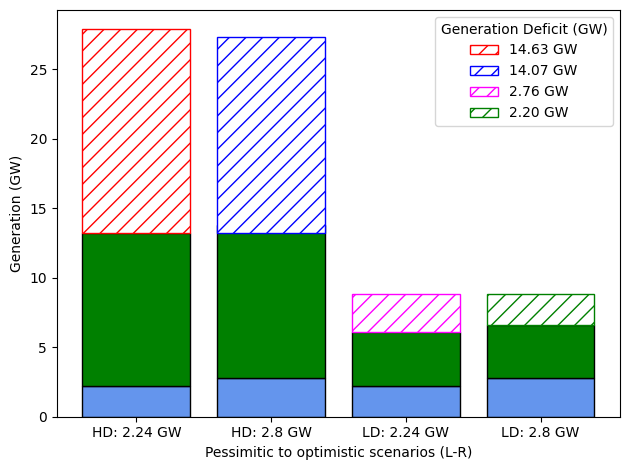

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# create data
x1 = ['HD: 2.24 GW']
x2 = ['HD: 2.8 GW']
x3 = ['LD: 2.24 GW']
x4 = ['LD: 2.8 GW']
PS1 = 2.24
PS2 = 2.8
HD1 = (27.87-2.24)
HD2 = (27.87-2.8)
LD1 = (8.83-2.24)
LD2 = (8.83-2.8)
REN1 = (25.63-11)
REN2 = 14.07
REN3 = 2.76
REN4 = 2.2

# plot bars in stack manner
alpha=1
color='cornflowerblue'
plt.bar(x1, PS1, color=color,edgecolor='black')
plt.bar(x1, HD1-REN1, bottom=PS1, color='green', edgecolor='black')
plt.bar(x1, REN1, bottom=HD1-REN1+PS1, color='white', alpha=alpha, hatch='//',edgecolor='red', label = '14.63 GW')

plt.bar(x2, y2, color=color,edgecolor='black')
plt.bar(x2, HD2-REN2, bottom=PS2, color='green', edgecolor='black')
plt.bar(x2, REN2, bottom=HD2-REN2+PS1, color='white', alpha=alpha, hatch='//',edgecolor='blue', label = '14.07 GW')

plt.bar(x3,PS1, color=color,edgecolor='black')
plt.bar(x3, LD1-REN3, bottom=PS1, color='green', edgecolor='black')
plt.bar(x3, REN3, bottom=LD1-REN3+PS1, color='white', alpha=alpha, hatch='//',edgecolor='magenta', label = '2.76 GW')

plt.bar(x4, PS2,color=color,edgecolor='black')
plt.bar(x4, LD2-REN4, bottom=PS2, color='green', edgecolor='black')
plt.bar(x4, REN4, bottom=LD2-REN4+PS2, color='white', alpha=alpha, hatch='//',edgecolor='green', label = '2.20 GW')


plt.ylabel("Generation (GW)")
plt.xlabel("Pessimitic to optimistic scenarios (L-R)")
plt.legend(ncol=1, title='Generation Deficit (GW)')
#plt.xticks(rotation=45, ha='right')

plt.tight_layout()  # prevents clipping
plt.show()

## Model 3: Increasing reliance on interconnectors (incomplete)

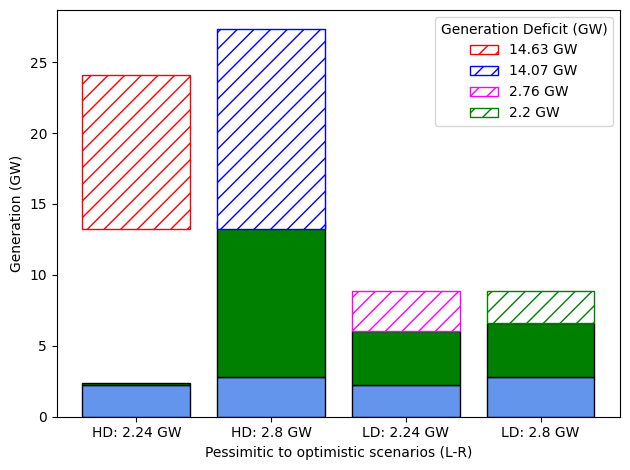

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# create data
x1 = ['HD: 2.24 GW']
x2 = ['HD: 2.8 GW']
x3 = ['LD: 2.24 GW']
x4 = ['LD: 2.8 GW']
PS1 = 2.24
PS2 = 2.8
HD1 = (27.87-2.24)
HD2 = (27.87-2.8)
LD1 = (8.83-2.24)
LD2 = (8.83-2.8)
REN1 = (25.63-11)
REN2 = 14.07
REN3 = 2.76
REN4 = 2.2
INTER1 = 10.85
INTER2 = 7.18
INTER3 = abs(-1.02)
INTER4 = abs(-4.69)

# plot bars in stack manner
alpha=1
color='cornflowerblue'
plt.bar(x1, PS1, color=color,edgecolor='black')
plt.bar(x1, HD1-REN1-INTER1, bottom=PS1, color='green', edgecolor='black')
plt.bar(x1, INTER1, bottom=HD1-REN1+PS1, color='white', alpha=alpha, hatch='//',edgecolor='red', label = '14.63 GW')

plt.bar(x2, y2, color=color,edgecolor='black')
plt.bar(x2, HD2-REN2, bottom=PS2, color='green', edgecolor='black')
plt.bar(x2, REN2, bottom=HD2-REN2+PS1, color='white', alpha=alpha, hatch='//',edgecolor='blue', label = '14.07 GW')

plt.bar(x3,PS1, color=color,edgecolor='black')
plt.bar(x3, LD1-REN3, bottom=PS1, color='green', edgecolor='black')
plt.bar(x3, REN3, bottom=LD1-REN3+PS1, color='white', alpha=alpha, hatch='//',edgecolor='magenta', label = '2.76 GW')

plt.bar(x4, PS2,color=color,edgecolor='black')
plt.bar(x4, LD2-REN4, bottom=PS2, color='green', edgecolor='black')
plt.bar(x4, REN4, bottom=LD2-REN4+PS2, color='white', alpha=alpha, hatch='//',edgecolor='green', label = '2.2 GW')


plt.ylabel("Generation (GW)")
plt.xlabel("Pessimitic to optimistic scenarios (L-R)")
plt.legend(ncol=1, title='Generation Deficit (GW)')
#plt.xticks(rotation=45, ha='right')

plt.tight_layout()  # prevents clipping
plt.show()